In [1]:
from diffrax import diffeqsolve, ODETerm
from jax.scipy.stats import norm,poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt


In [2]:
mu = jnp.log(1.0)

t_vec = jnp.linspace(0,20,100)

def rhs(t,state,args):

    x,y = state
    mu = args
    #exponentiate to enforce positivity
    mu = jnp.exp(mu)

    # Nonlinear cubic term introduces limit cycle behavior.
    dx = mu * (x - 1/3 * x**3 - y)
    # Coupling term creates slow–fast dynamics when mu is large.
    dy = 1/mu * x


    return jnp.array([dx,dy])

In [3]:
'''The model integrator. Takes the length of time to integrate, the initial condition, and a parameter vector.'''
def model(ts,y0,par):
  solution = diffrax.diffeqsolve(
            ODETerm(rhs),
            diffrax.Tsit5(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            args=par,
            stepsize_controller = diffrax.PIDController(rtol=1e-5, atol=1e-5),
            saveat=diffrax.SaveAt(ts=ts) #At which points to save the output
        )
  return solution.ys

In [4]:
# Initializing the random number generator
rng_key = jax.random.PRNGKey(0)

# Split the key to avoid reusing the same key.
# JAX requires explicit key management.
noise_key,rng_key = jax.random.split(rng_key)

'''Simulate model'''
# Initial condition: x(0)=3.0, y(0)=0.5
full_state = model(t_vec,jnp.array([3.,0.5]),(mu))

# Generate noisy observations of the first state component x(t) with additive Gaussian noise ~N(0,1).
noise_std = 1.0
observations = full_state[:,0] + noise_std * jax.random.normal(noise_key,shape = full_state[:,0].shape)


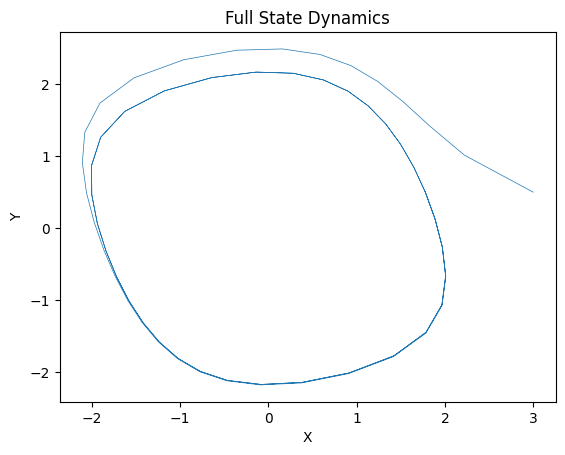

In [5]:
# Numerical solution of the ODE in x(t), y(t)
plt.plot(full_state[:,0],full_state[:,1],lw = 0.5)
plt.title('Full State Dynamics')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

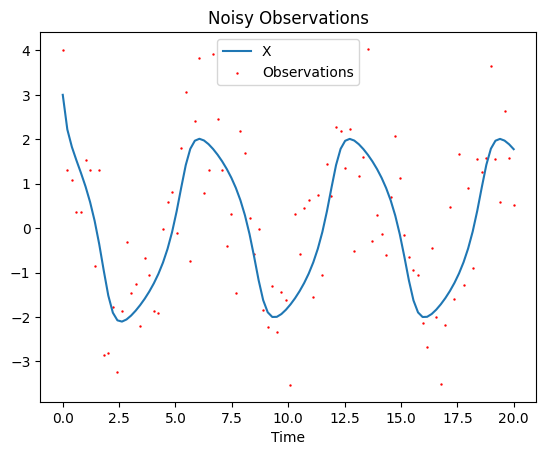

In [6]:
# Numerical solution of the ODE in t,x(t)
# We assume that the obervations are the red dots
plt.title('Noisy Observations')
plt.plot(t_vec,full_state[:,0],label = 'X')
plt.scatter(t_vec,observations,s = 0.5,color = 'red', label = 'Observations')
plt.xlabel('Time')
plt.legend()
plt.show()

In [7]:
@jax.jit
def log_likelihood(par):
  mu,noise_std,x_init,y_init = par
  model_output = model(t_vec,jnp.array([x_init,y_init]),(mu))
  return jnp.sum(jax.scipy.stats.norm.logpdf(observations, model_output[:,0],scale = jnp.exp(noise_std)))

In [8]:
def hmc(n_samples, x_init, n_steps, step_size,key):
    """Run Hamiltonian Monte Carlo to draw `n_samples` from the log density
    `logp`, starting at initial state `x0`.
    """
    r_scale = 1
    M = (r_scale**2) * jnp.eye(x_init.shape[0])

    # Kinetic and potential energy functions.
    T = lambda r: 1/2 * (r.T @ M @ r)
    V = lambda x: -log_likelihood(x)

    grad_V = jax.jit(jax.grad(V))

    acc_record = jnp.zeros((n_samples,))

    dim = len(x_init)
    samples = jnp.zeros((n_samples, dim))
    samples = samples.at[0,:].set(x_init)

    for iter in range(1, n_samples):

        #if(iter % 100 == 0):
             #print the acceptance rate and likelihood every 10 iterations
        print(f"iteration: {iter} | Acceptance rate: {jnp.sum(acc_record[:iter])/iter} | param vec: {jnp.exp(samples[iter-1,:])}",end = '\r')

        x_curr = samples[iter-1,:]
        key, key_r = jax.random.split(key)
        r_curr = r_scale * jax.random.normal(key = key_r, shape=(dim,))

        ### Leapfrog integrator
        x_prop, r_prop = x_curr, r_curr
        for _ in range(n_steps):
            r_prop = r_prop - (step_size / 2) * grad_V(x_prop)
            x_prop = x_prop + step_size * r_prop
            r_prop = r_prop - (step_size / 2) * grad_V(x_prop)
        #End leapfrog integrator

        H_prop = T(r_prop) + V(x_prop)
        H_curr = T(r_curr) + V(x_curr)
        alpha  = jnp.exp(-H_prop + H_curr)

        key, accept_key = jax.random.split(key)
        if jax.random.uniform(minval = 0, maxval = 1, key = accept_key) < alpha:
            x_curr = x_prop
            acc_record = acc_record.at[iter].set(1)

        samples = samples.at[iter,:].set(x_curr)

    return samples

In [9]:
rng_key, init_key = jax.random.split(rng_key)
rng_key, hmc_key = jax.random.split(rng_key)

samples = hmc(
    n_samples=1000,
    x_init=jnp.array([jnp.log(0.5),jnp.log(0.5),1.,1.]),
    n_steps=10,
    step_size=0.01,
    key = hmc_key
)

KeyboardInterrupt: 

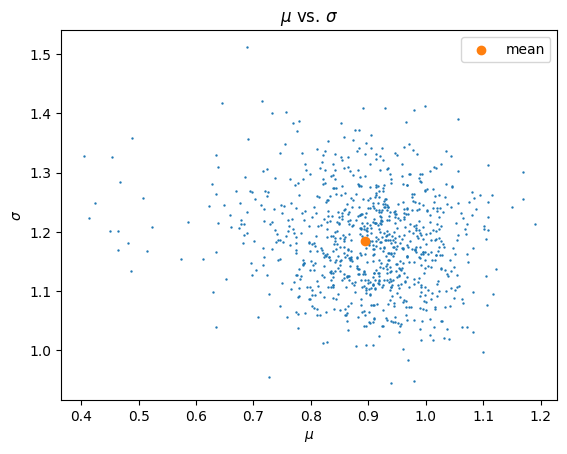

In [ ]:
burn_in = 100

plt.title('$\\mu$ vs. $\\sigma$')
plt.xlabel('$\\mu$')
plt.ylabel("$\\sigma$")

plt.scatter(jnp.exp(samples[burn_in:,0]),jnp.exp(samples[burn_in:,1]),s = 0.5)

mean = jnp.mean(jnp.exp(samples[burn_in:]),axis = 0)
plt.scatter(mean[0],mean[1],label = 'mean')
plt.legend()

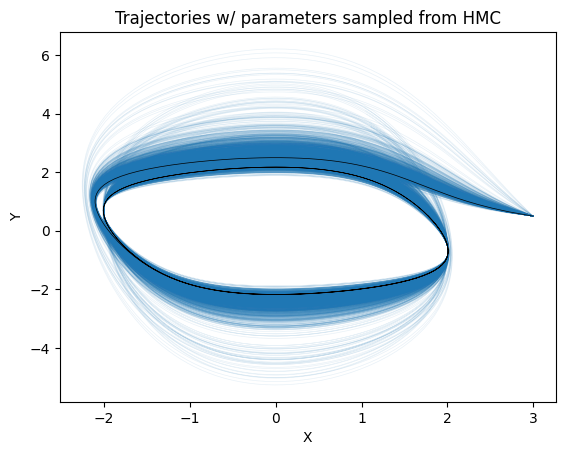

In [ ]:
plt.title('Trajectories w/ parameters sampled from HMC')
plt.xlabel('X')
plt.ylabel('Y')
t_vec = t_vec = jnp.linspace(0,20,400)
for sample_index in range(burn_in,len(samples)):
    sample = samples[sample_index,:]
    full_state = model(t_vec,jnp.array([samples[2],samples[3]]),(sample[0]))
    plt.plot(full_state[:,0],full_state[:,1],color = 'tab:blue',alpha = 0.1,lw = 0.5)

full_state = model(t_vec,jnp.array([3.,0.5]),(mu))
plt.plot(full_state[:,0],full_state[:,1],color = 'black',lw = 0.5)
plt.show()